# 저전력 온디바이스 AI 기반 위험구역 침입 감지 — 학습 및 성능 평가

**클래스** : `0 baby` · `1 adult` · `2 knife` · `3 outlet`
**데이터** : `merged_v3.zip` (train 621장 / test 189장,
박스 baby 250 · adult 330 · knife 153 · outlet 212)

> **먼저 할 것** : 메뉴 `런타임 → 런타임 유형 변경 → T4 GPU`
> CPU로 두면 10분짜리가 2시간이 된다. T4에서 640·320 두 번 학습에 약 18분.


## 0. 지표 읽는 법 — 결과 보기 전에

| 지표 | 뜻 | 낮으면 |
|---|---|---|
| **Precision (정밀도)** | 있다고 한 것 중 진짜인 비율 | **오검출**이 많다 |
| **Recall (재현율)** | 실제 있는 것 중 찾아낸 비율 | **놓친다** |
| **mAP50** | 박스가 대충 맞으면 정답 처리 | 아예 못 찾는다 |
| **mAP50-95** | 박스 정확도까지 엄격하게 채점 | 찾긴 하는데 박스가 어긋난다 |

우리 시나리오는 **아기를 놓치면 사고**다. 그래서 **Recall이 Precision보다 중요**하다.
보고서에 mAP만 쓰지 말고 Precision/Recall을 같이 쓸 것.


## 1. 환경


In [ ]:
!pip -q install "ultralytics==8.4.98"    # 강사님 EX_02와 같은 버전
import torch, ultralytics, os, json, glob, collections
print('ultralytics', ultralytics.__version__)
print('GPU :', torch.cuda.get_device_name(0) if torch.cuda.is_available() else '없음 — 런타임을 T4로 바꾸세요')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ultralytics 8.4.98
GPU : Tesla T4


## 2. 데이터 올리기

아래 셀을 실행하면 파일 선택 창이 뜬다. PC에서 이 파일을 고른다.

```
C:\\Users\kccistc\Developer\침입감지_프로젝트\merged_v3.zip
```

36 MB라 올리는 데 1~2분 걸린다. 파일명은 아무거나 상관없고,
압축 안에서 `images` / `labels` 가 있는 폴더를 자동으로 찾는다.


In [ ]:
from google.colab import files
up = files.upload()          # merged_v3.zip 선택 (파일명 아무거나 상관없음)

import zipfile, os
for z in up:
    with zipfile.ZipFile(z) as f:
        f.extractall('/content/')
    print('풀었음 :', z)

# 압축을 푼 뒤 images/labels 가 있는 폴더를 찾아 ROOT 로 잡는다
ROOT = None
for r, d, _ in os.walk('/content'):
    if 'images' in d and 'labels' in d and '/out' not in r:
        ROOT = r; break
assert ROOT, '데이터 폴더를 못 찾았습니다.'
print('ROOT :', ROOT)
print(sorted(os.listdir(ROOT)))


Saving merged.zip to merged.zip
data.yaml  images  labels


### data.yaml 경로 고치기
PC에서 만든 파일이라 경로가 윈도우 기준이다. Colab 경로로 바꾼다.


In [ ]:
# data.yaml 을 Colab 경로에 맞게 다시 만든다
import os
CLASSES = ['baby', 'adult', 'knife', 'outlet']
val_dir = 'images/val' if os.path.isdir(os.path.join(ROOT, 'images', 'val')) else 'images/test'

lines = []
lines.append('path: ' + ROOT)
lines.append('train: images/train')
lines.append('val: ' + val_dir)
lines.append('')
lines.append('nc: ' + str(len(CLASSES)))
lines.append('names:')
for i, c in enumerate(CLASSES):
    lines.append('  ' + str(i) + ': ' + c)

y = os.path.join(ROOT, 'data.yaml')
open(y, 'w', encoding='utf-8').write(chr(10).join(lines) + chr(10))
print(open(y, encoding='utf-8').read())


path: /content/merged
train: images/train
val: images/val

nc: 4
names:
  0: baby
  1: adult
  2: knife
  3: outlet


## 3. 데이터 점검 — 학습 전에 반드시
클래스별 박스 수가 **0이면 그 클래스는 아예 못 배운다.**


In [ ]:
CLASSES = ['baby', 'adult', 'knife', 'outlet']

for sp in ['train', 'val', 'test']:
    di, dl = os.path.join(ROOT,'images',sp), os.path.join(ROOT,'labels',sp)
    if not os.path.isdir(di):
        continue
    c, nl = collections.Counter(), 0
    for f in os.listdir(dl):
        if f.endswith('.txt') and f != 'classes.txt':
            nl += 1
            for line in open(os.path.join(dl, f)):
                if line.strip():
                    c[int(line.split()[0])] += 1
    print('[%s] 사진 %d장 / 라벨 %d개' % (sp, len(os.listdir(di)), nl))
    for i, name in enumerate(CLASSES):
        mark = '   <-- 데이터 없음!' if not c[i] else ''
        print('    %d %-8s %5d개%s' % (i, name, c[i], mark))
    print()


[train] 사진 455장 / 라벨 455개
    0 baby       185개
    1 adult        0개   <-- 데이터 없음!
    2 knife      123개
    3 outlet     166개

[val] 사진 133장 / 라벨 133개
    0 baby        65개
    1 adult        0개   <-- 데이터 없음!
    2 knife       31개
    3 outlet      46개



## 4. 학습 — 640과 320을 둘 다 돌려 비교한다

보드에서는 **320**으로 추론한다. 그런데 학습도 320으로 해야 좋은지,
640으로 크게 배워 두고 320으로 줄여 쓰는 게 좋은지는 **해 봐야 안다.**
그래서 두 번 돌리고, 둘 다 **320으로 평가**해서 고른다.

| 값 | 뜻 |
|---|---|
| `epochs=60` | 데이터 전체를 60번 반복 |
| `imgsz=640` / `320` | 학습 입력 크기. 두 번 돌린다 |
| `batch=16` / `32` | 320은 가벼워서 한 번에 더 많이 넣을 수 있다 |
| `cache=True` | 사진을 RAM에 올려 로딩 대기 제거 |
| `patience=20` | 20번 동안 안 좋아지면 일찍 멈춤 |
| `fliplr=0.5` | 절반을 좌우 반전 |
| `degrees=10` | ±10도 회전 (기울여 놓인 물체 대비) |
| `seed=0` | **고정.** 안 하면 돌릴 때마다 결과가 달라져 비교가 안 된다 |

T4에서 640은 약 12분, 320은 약 6분.


In [ ]:
# 학습 입력 크기를 640 / 320 두 가지로 돌려서 비교한다.
#   보드에서는 320 으로 추론하므로, 학습도 320 이 나은지 640 이 나은지 확인한다.
#   640 은 약 20분, 320 은 약 5분 (T4 기준).
from ultralytics import YOLO
import os

RUNS = {}
for SZ in (640, 320):
    print('=' * 60)
    print(' 학습 시작 : imgsz =', SZ)
    print('=' * 60)
    m = YOLO('yolo11n.pt')
    m.train(
        data=os.path.join(ROOT, 'data.yaml'),
        imgsz=SZ,
        epochs=60,
        batch=32 if SZ == 320 else 16,
        cache=True,
        patience=20,
        fliplr=0.5, degrees=10.0,
        seed=0, deterministic=True,
        project='/content/runs', name='train%d' % SZ,
        exist_ok=True, plots=True, verbose=False,
    )
    RUNS[SZ] = '/content/runs/train%d/weights/best.pt' % SZ
    print('완료 :', RUNS[SZ])

print()
print(RUNS)


New https://pypi.org/project/ultralytics/8.4.157 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.98 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/merged/data.yaml, degrees=10.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_sc

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f39801cc360>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

## 5. 평가 — 성능 요약표
**이 표를 그대로 보고서에 넣는다.**


In [ ]:
# 두 모델을 모두 320 으로 평가한다 (보드에서 쓸 조건)
import pandas as pd
from ultralytics import YOLO

CLASSES = ['baby', 'adult', 'knife', 'outlet']
rows = []
for sz, w in RUNS.items():
    for eval_sz in sorted({sz, 320}):   # 320 학습이면 한 번만
        r = YOLO(w).val(data=os.path.join(ROOT, 'data.yaml'),
                        imgsz=eval_sz, plots=(eval_sz == sz),
                        name='val%d_at%d' % (sz, eval_sz),
                        project='/content/runs', exist_ok=True, verbose=False)
        rows.append({'학습입력': sz, '평가입력': eval_sz,
                     '정밀도': round(float(r.box.mp), 3),
                     '재현율': round(float(r.box.mr), 3),
                     'mAP50': round(float(r.box.map50), 4),
                     'mAP50-95': round(float(r.box.map), 4)})
        if eval_sz == sz:
            for i, ci in enumerate(r.box.ap_class_index):
                rows[-1]['AP50_' + CLASSES[int(ci)]] = round(float(r.box.ap50[i]), 4)

df = pd.DataFrame(rows)
print(df.to_string(index=False))
os.makedirs('/content/out', exist_ok=True)
df.to_csv('/content/out/학습크기_비교.csv', index=False, encoding='utf-8-sig')

# 보드 조건(320 평가)에서 더 좋은 쪽을 고른다
at320 = [r for r in rows if r['평가입력'] == 320]
best = max(at320, key=lambda r: r['mAP50-95'])
BEST_W = RUNS[best['학습입력']]
print()
print('320 으로 평가했을 때 더 좋은 쪽 : 학습입력', best['학습입력'],
      ' mAP50-95', best['mAP50-95'])
print('이 모델을 tflite 로 변환한다 :', BEST_W)


Ultralytics 8.4.98 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1788.9±491.5 MB/s, size: 55.6 KB)
val: Scanning /content/merged/labels/val.cache... 133 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 133/133 46.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 3.7it/s 2.4s
                   all        133        142      0.991       0.98      0.979      0.872
                  baby         65         65      0.999          1      0.995      0.891
                 knife         31         31          1      0.941      0.965      0.907
                outlet         46         46      0.975          1      0.978      0.816
Speed: 2.9ms preprocess, 5.3ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to /content/runs/detect/val
지표              

## 6. 그래프 — Ultralytics가 자동으로 만든 것

| 파일 | 무엇을 보는가 |
|---|---|
| `results.png` | **학습 곡선.** loss가 내려가고 mAP가 올라가는지. 끝에서 평평하면 충분히 학습된 것 |
| `confusion_matrix_normalized.png` | **무엇을 무엇으로 착각하는지.** 대각선이 진할수록 좋다 |
| `BoxPR_curve.png` | 정밀도-재현율 곡선. 곡선 아래 넓이가 mAP |
| `BoxF1_curve.png` | **판정 임계값을 몇으로 둘지** 고를 때 본다. 꼭대기가 최적 |
| `BoxP_curve.png` / `BoxR_curve.png` | 임계값에 따른 정밀도 / 재현율 |
| `labels.jpg` | 박스 크기·위치 분포. 데이터가 한쪽에 쏠렸는지 |
| `val_batch0_labels.jpg` | 정답 |
| `val_batch0_pred.jpg` | **모델 예측.** 위 정답과 나란히 비교하면 어디서 틀리는지 보인다 |

> 검출(detect) 작업의 곡선 파일에는 앞에 **`Box`** 가 붙는다.


### results.png

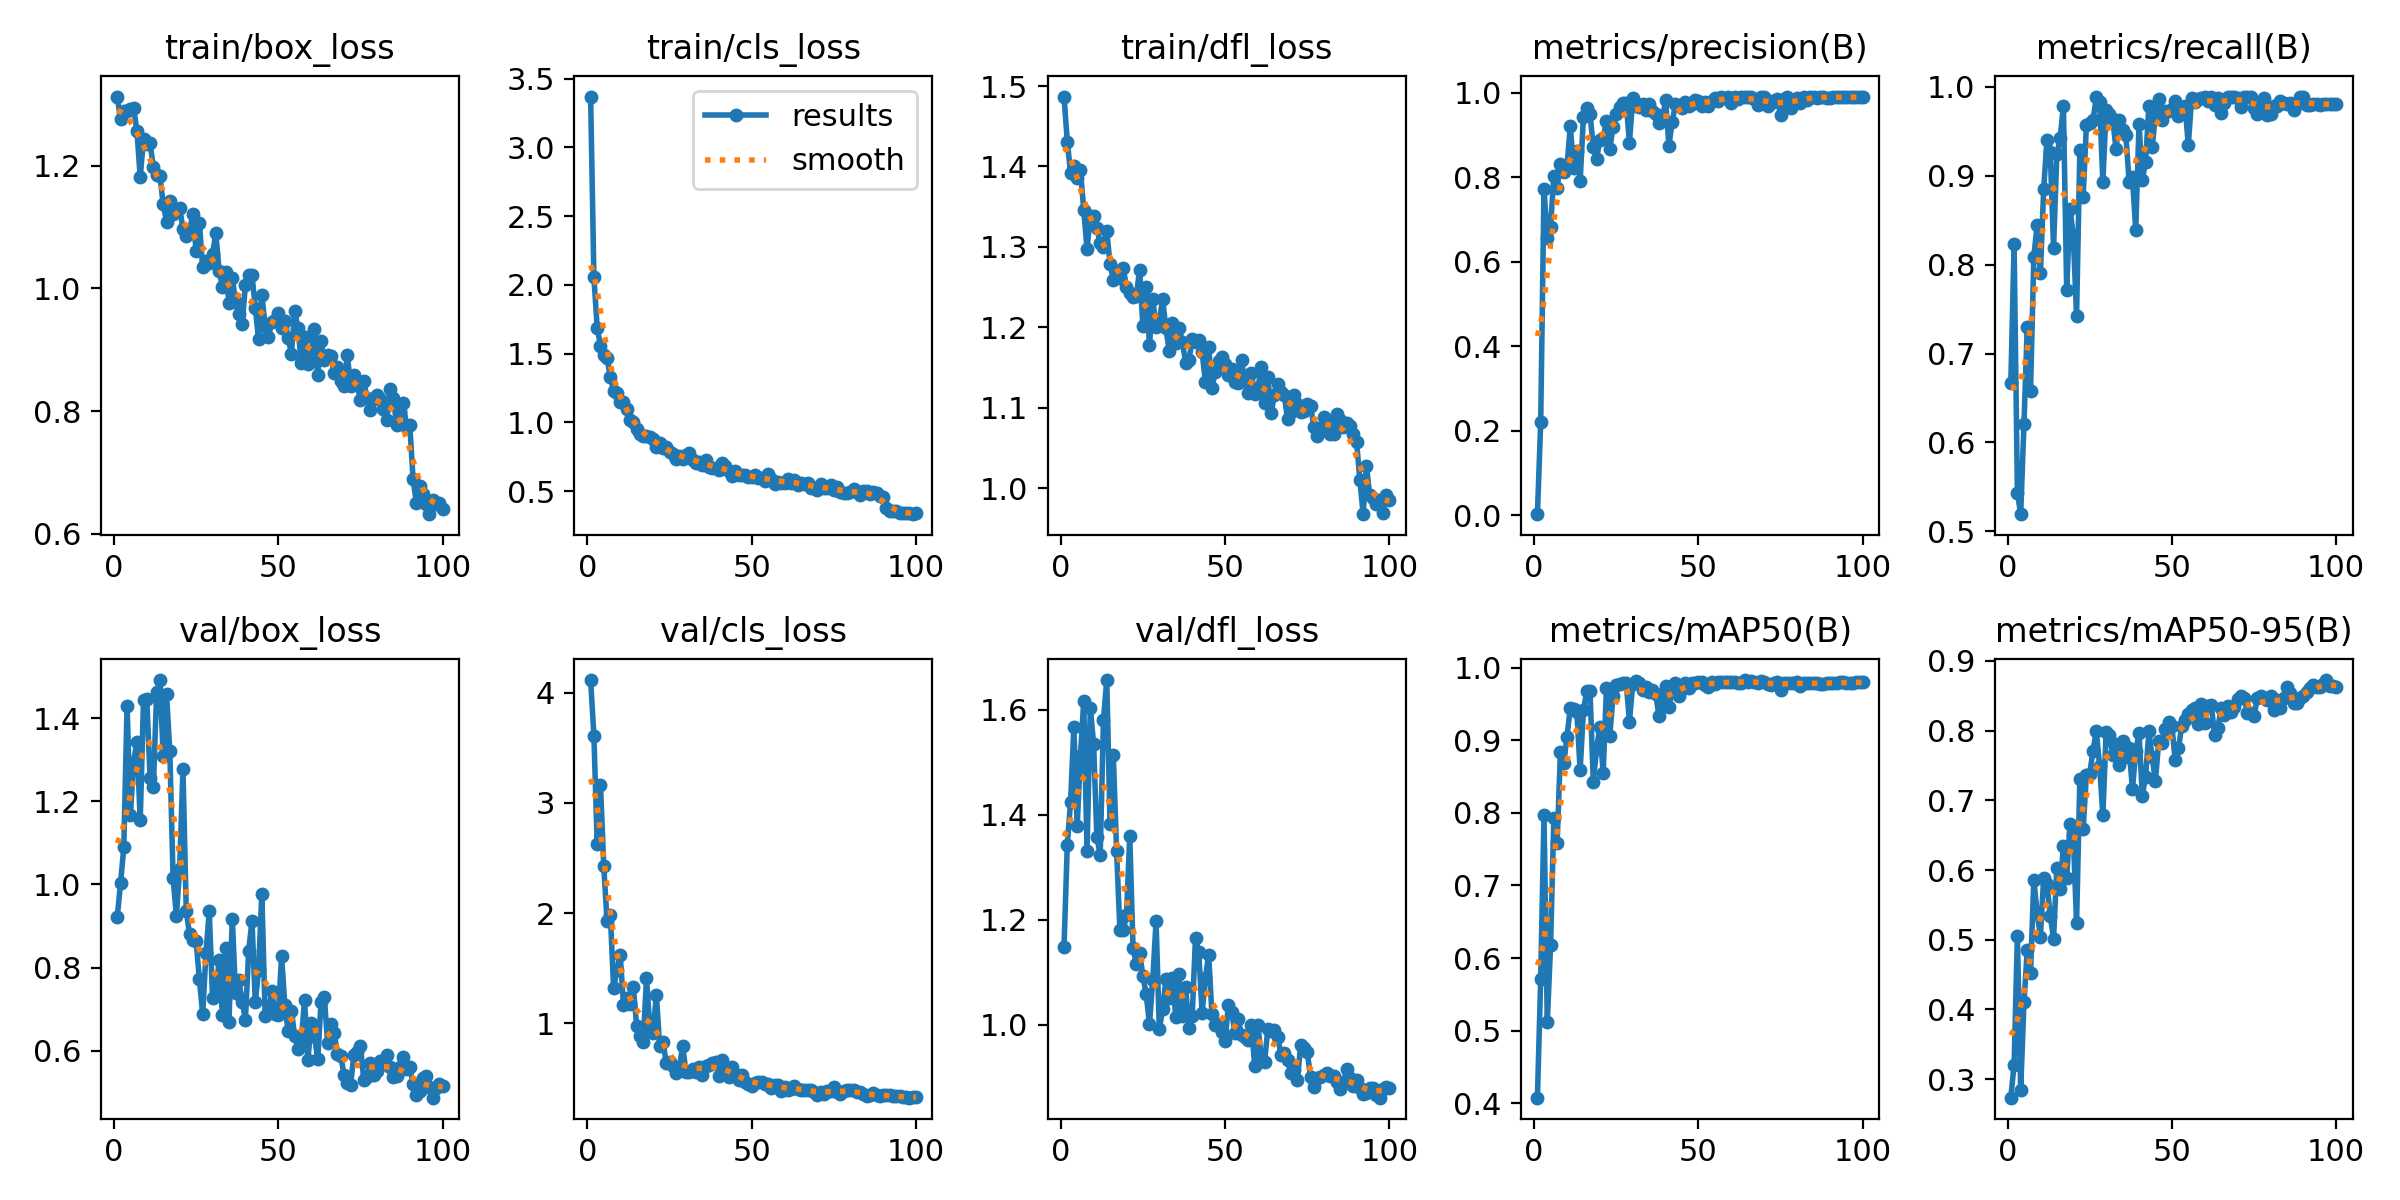

### confusion_matrix_normalized.png

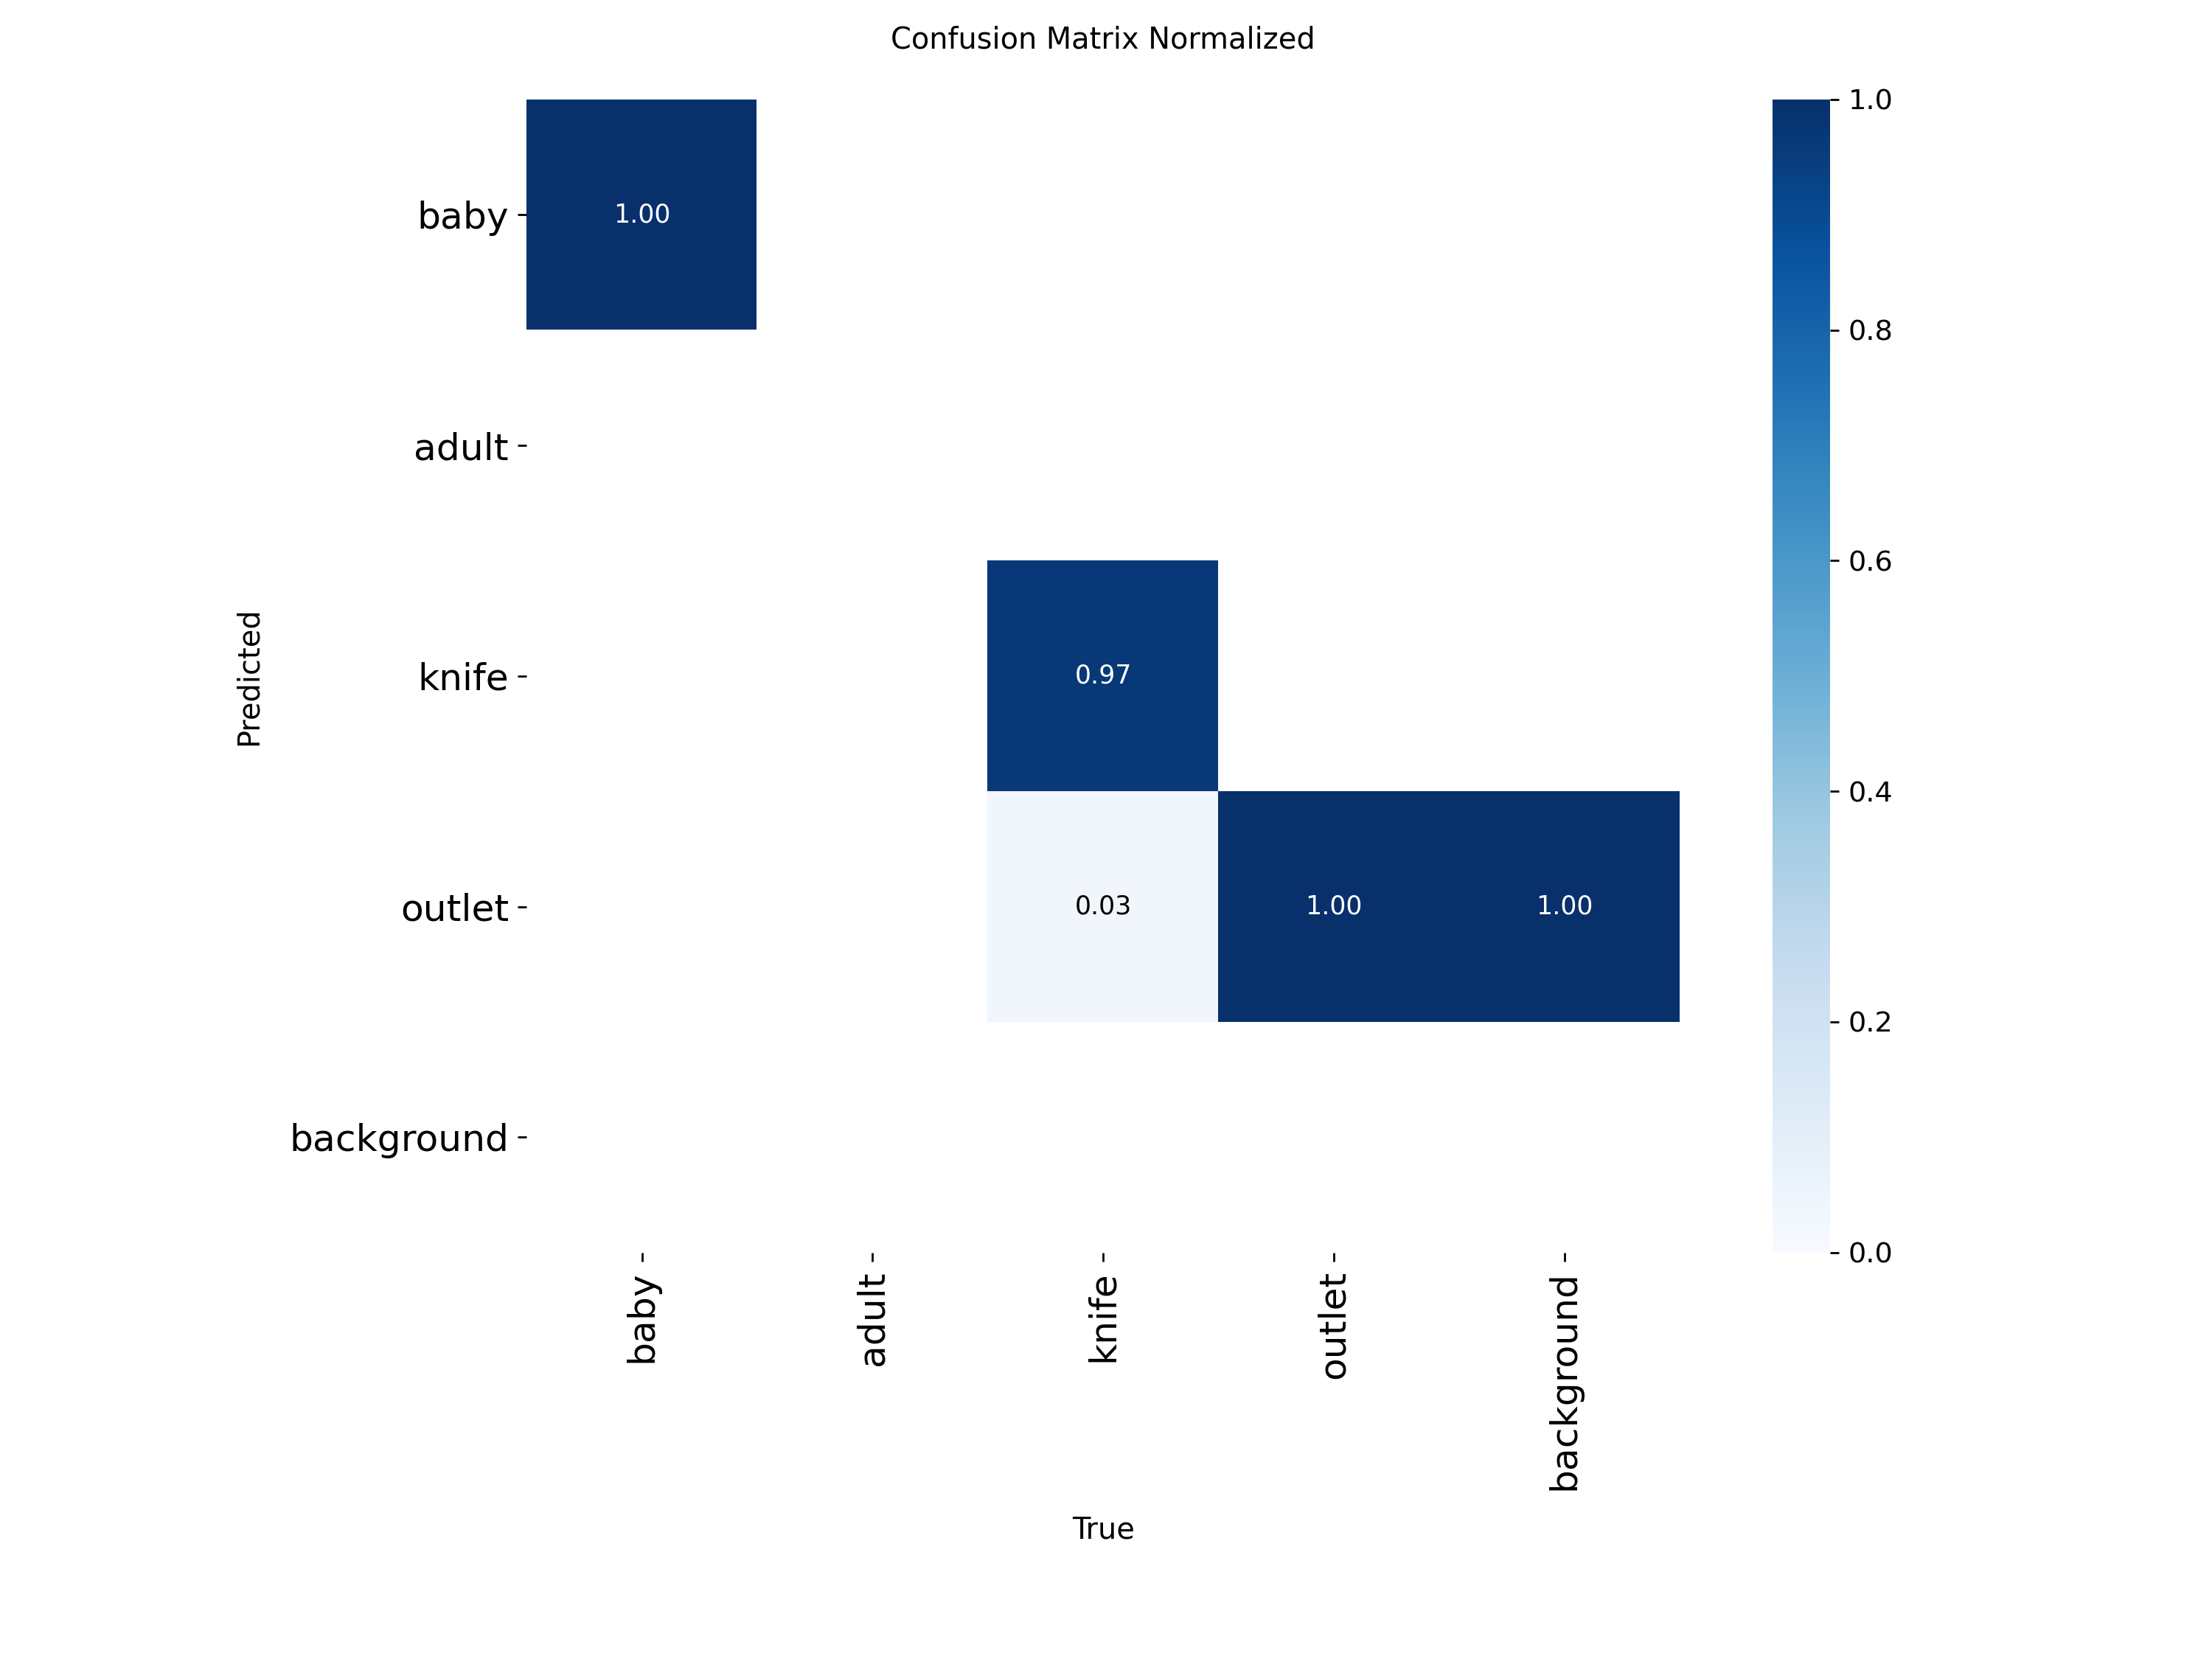

### confusion_matrix.png

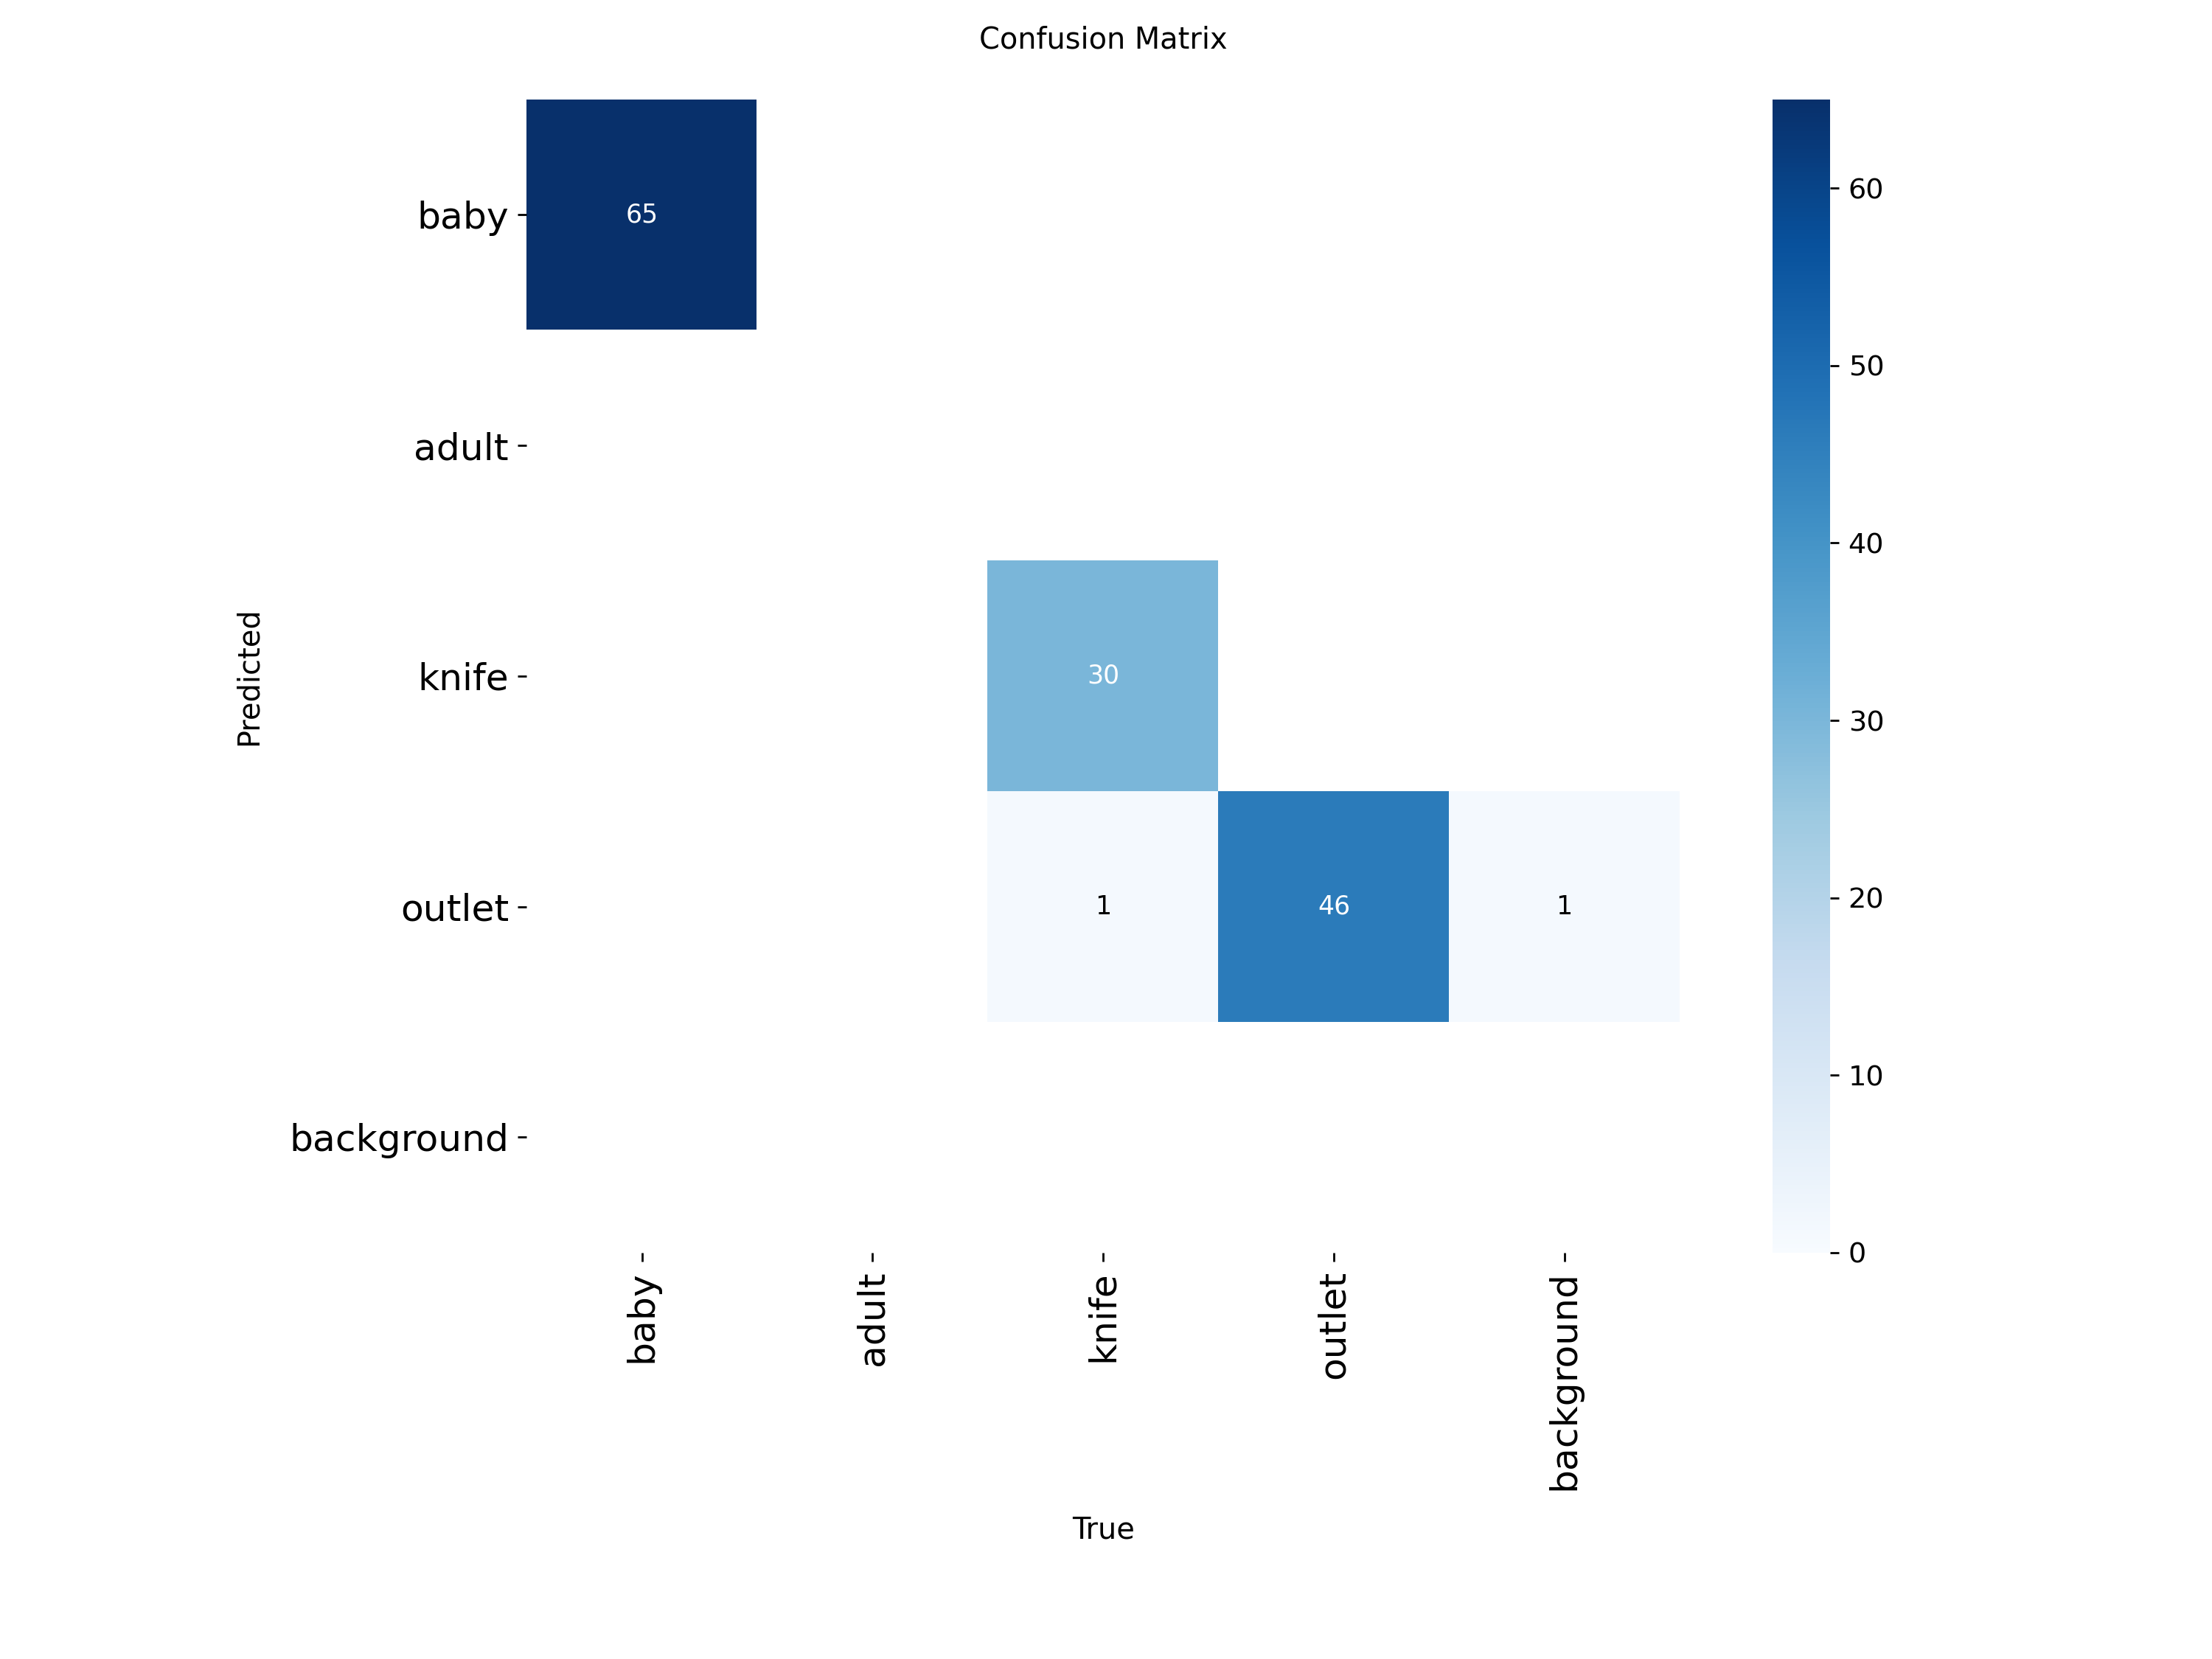

### labels.jpg

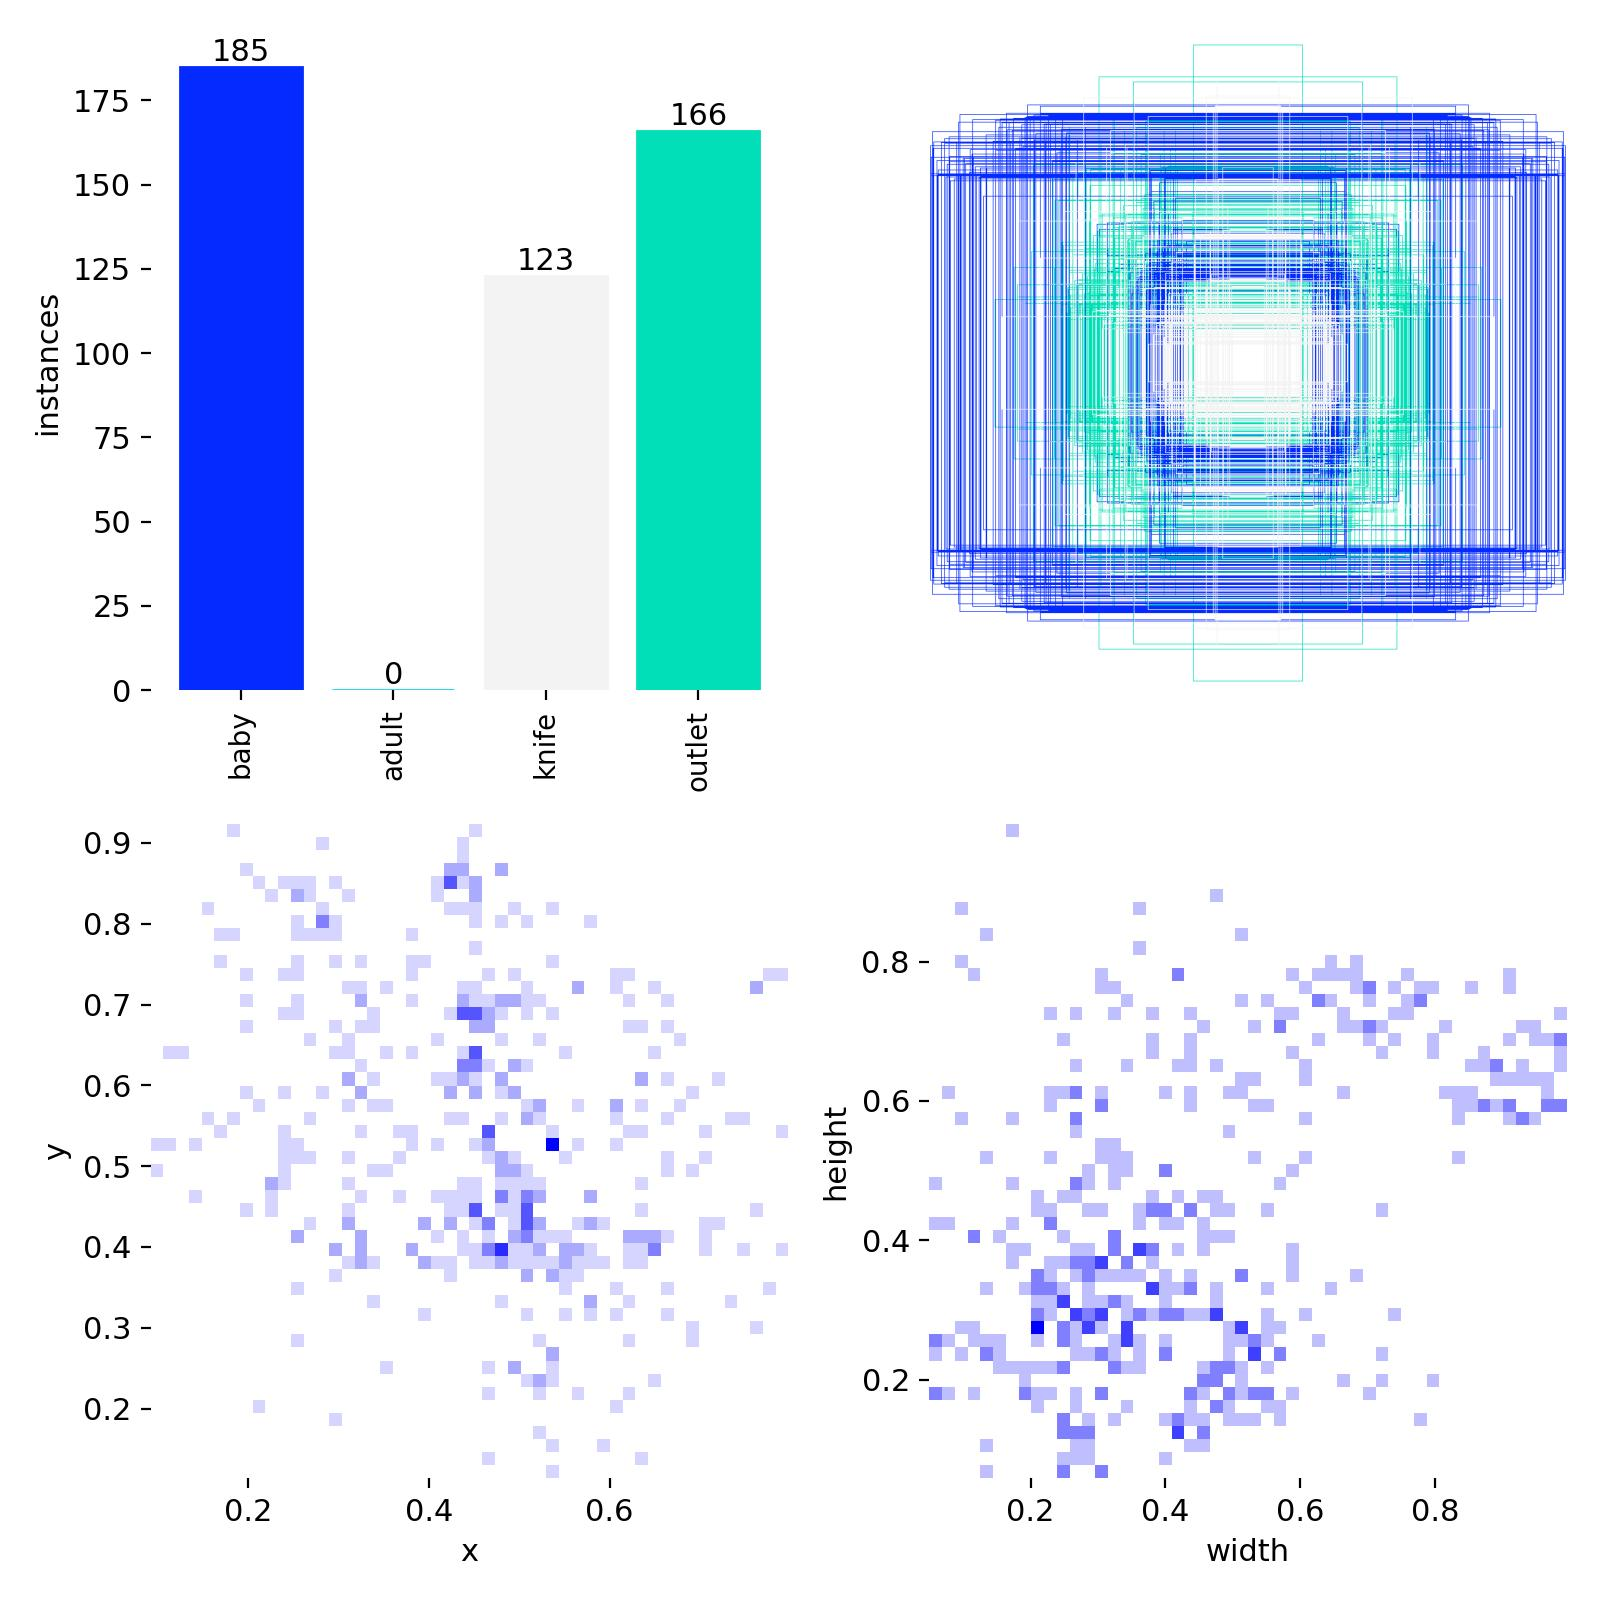

### val_batch0_labels.jpg

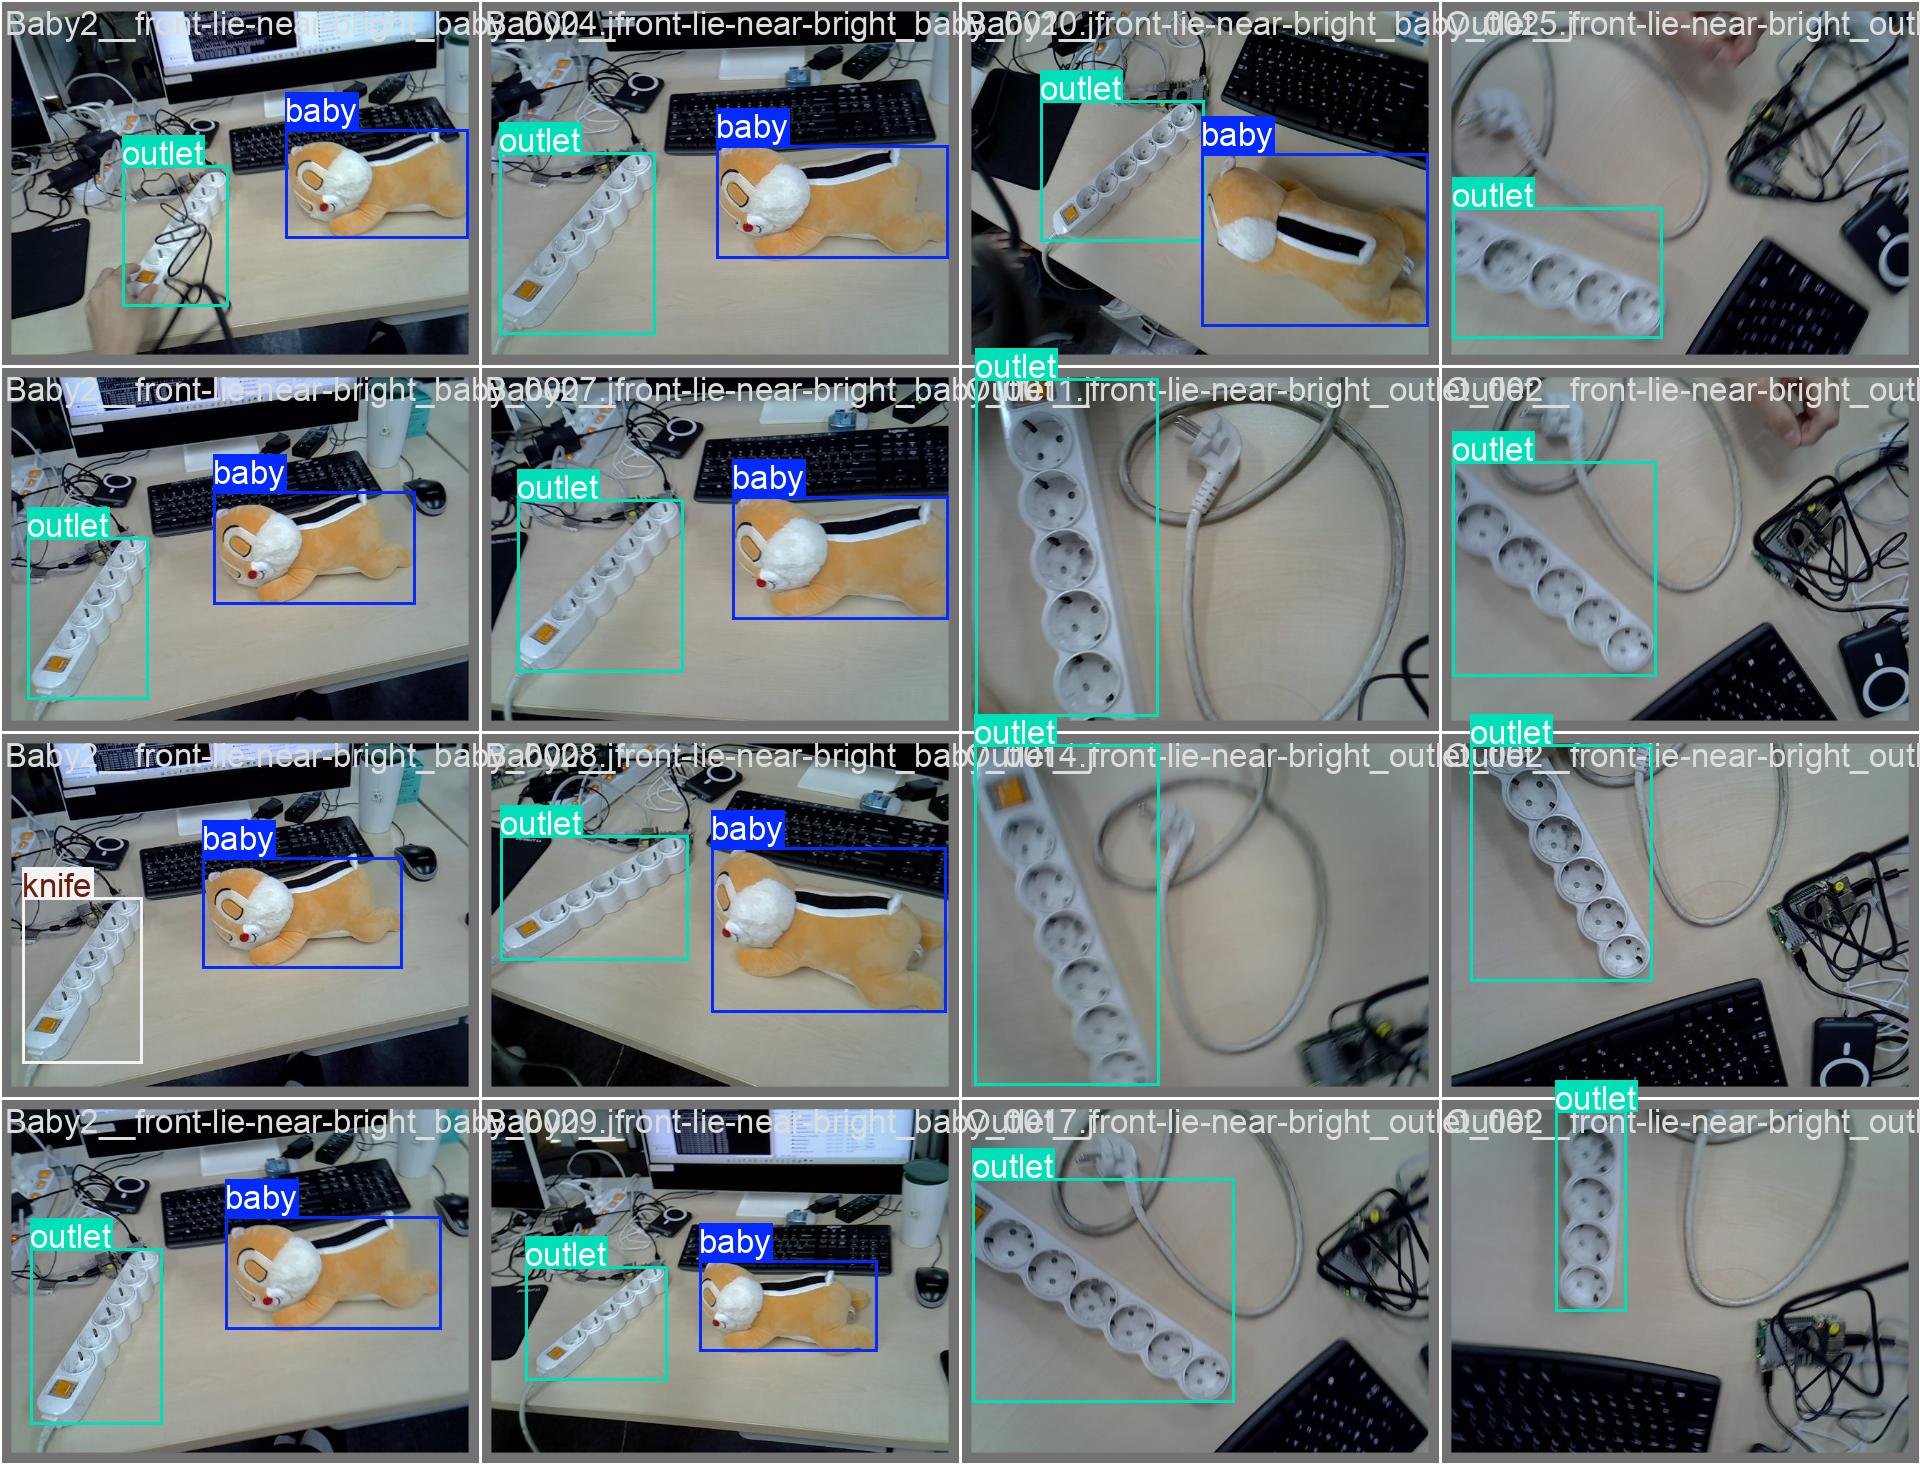

### val_batch0_pred.jpg

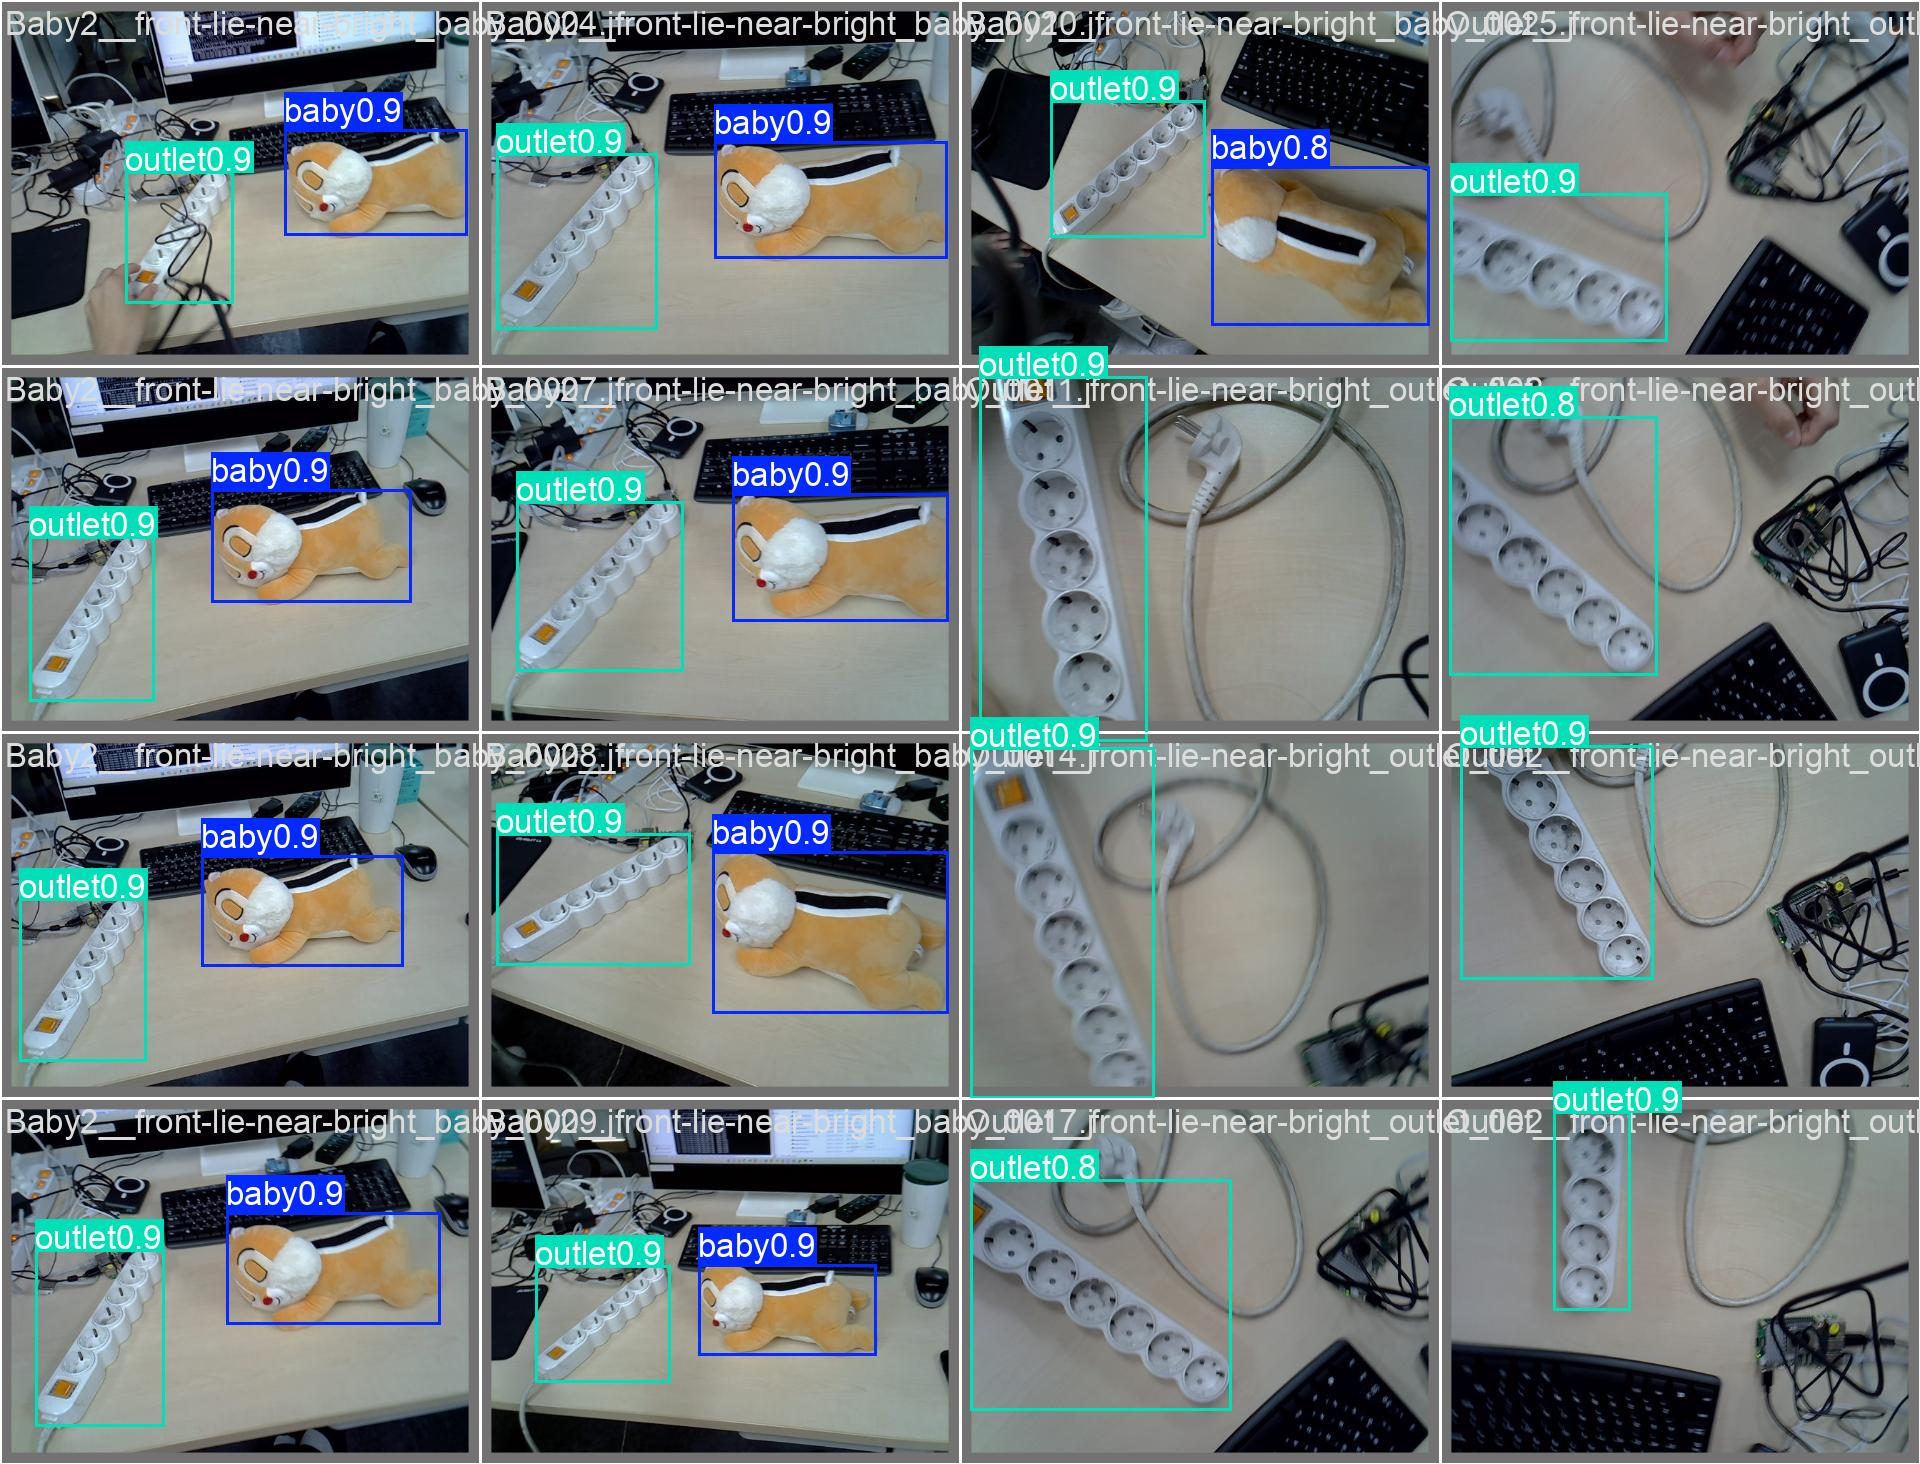

In [ ]:
# 그래프 모아 보기
#   주의 : Ultralytics 는 검출 곡선을 BoxPR_curve.png 처럼 'Box' 를 붙여 저장한다.
#          이름을 고정해 두면 조용히 빠지므로 *curve*.png 로 훑는다.
from IPython.display import Image, display, Markdown
import glob, os

shown = set()
groups = [('학습 곡선', ['/content/runs/**/results.png']),
          ('혼동 행렬', ['/content/runs/**/confusion_matrix_normalized.png',
                       '/content/runs/**/confusion_matrix.png']),
          ('정밀도·재현율·F1 곡선', ['/content/runs/**/*curve*.png']),
          ('데이터 분포', ['/content/runs/**/labels.jpg']),
          ('정답 vs 예측', ['/content/runs/**/val_batch0_labels.jpg',
                          '/content/runs/**/val_batch0_pred.jpg'])]

for title, pats in groups:
    fs = []
    for p in pats:
        fs += sorted(glob.glob(p, recursive=True))
    # 같은 이름이면 train640 것 하나만
    pick = {}
    for f in fs:
        n = os.path.basename(f)
        if n not in pick or 'train640' in f:
            pick[n] = f
    if not pick:
        print('[없음]', title)
        continue
    display(Markdown('## ' + title))
    for n, f in sorted(pick.items()):
        if f in shown:
            continue
        shown.add(f)
        display(Markdown('**%s**  `%s`' % (n, f)))
        display(Image(filename=f, width=760))


## 7. 클래스별 막대그래프
표보다 그림이 보고서에서 눈에 잘 들어온다.


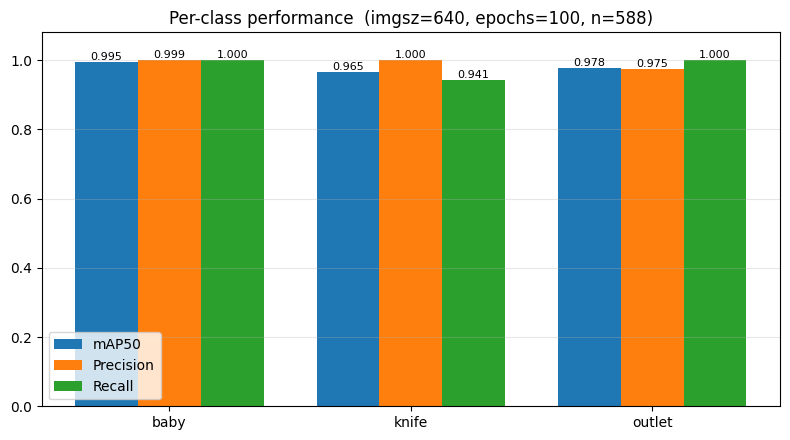

In [ ]:
# (클래스별 막대그래프는 비교표로 대체)


## 8. 눈으로 확인 — 실제 예측
숫자만 보면 안 된다. **어디서 틀리는지**는 사진을 봐야 안다.

성공한 것뿐 아니라 **틀린 것도 보고서에 넣어야** 분석이 된다.


In [ ]:
vd = os.path.join(ROOT, 'images', 'val')
if not os.path.isdir(vd):
    vd = os.path.join(ROOT, 'images', 'test')
imgs = sorted(glob.glob(vd + '/*.jpg'))
pick = imgs[::max(1, len(imgs)//8)][:8]      # 고르게 8장
YOLO(BEST_W).predict(pick, conf=0.25, save=True,
              project='/content/runs', name='pred', exist_ok=True)
for f in sorted(glob.glob('/content/runs/**/pred/*.jpg', recursive=True))[:8]:
    display(Image(filename=f, width=520))



0: 480x640 1 baby, 1 outlet, 6.0ms
1: 480x640 1 outlet, 6.0ms
2: 480x640 1 outlet, 6.0ms
3: 480x640 1 baby, 6.0ms
4: 480x640 1 baby, 6.0ms
5: 480x640 1 baby, 6.0ms
6: 480x640 1 baby, 6.0ms
7: 480x640 1 knife, 6.0ms
Speed: 1.7ms preprocess, 6.0ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/runs/pred


## 9. tflite 변환 — 보드에서 쓸 모델

**교수님 EX_02와 똑같은 명령을 쓴다.** 이게 중요하다.

`format=litert` 는 PyTorch에서 바로 변환하는 경로라 입력이 **(1,3,320,320) NCHW** 로 나온다.
`format=tflite` 로 내보내면 **(1,320,320,3) NHWC** 가 되어 보드 예제 코드와 형태가 달라진다.
형태가 다르면 오류가 나거나 — 더 나쁘게는 **엉뚱한 결과가 조용히 나온다.**

| 모델 | 크기 | 무엇 |
|---|---|---|
| `best.tflite` (float32) | 약 10 MB | 기준. 변환만 하고 양자화는 안 함 |
| `best_int8.tflite` | 약 2.9 MB | 가중치도 계산도 8비트 (`quantize=8`) |
| `best_w8a32.tflite` | 약 2.8 MB | 가중치만 8비트, 계산은 32비트 (`quantize=w8a32`) |

**셋 중 뭘 쓸지는 이 셀의 표와 보드 속도 측정(`bench_models.py`)을 보고 정한다.**
정확도는 여기서, 속도는 보드에서. 둘을 같이 봐야 고를 수 있다.

입력을 **320**으로 줄인다. 보드 CPU에서 640은 너무 느리다.


In [ ]:
# tflite 변환 3종 + 정확도 비교 (INT8 / w8a32 포함)
!pip -q install ai-edge-litert

import glob, os
import pandas as pd
from ultralytics import YOLO

DATA = os.path.join(ROOT, 'data.yaml')
cands = [BEST_W] if 'BEST_W' in dir() else sorted(glob.glob('/content/**/weights/best.pt', recursive=True))
assert cands, 'best.pt 를 못 찾았습니다.'
BEST = cands[0]
WDIR = os.path.dirname(BEST)
print('모델 :', BEST)

# ── 변환 (이미 있으면 건너뜀) ──
sh = get_ipython().system
for fname, opt in [('best.tflite', ''),
                   ('best_int8.tflite', 'quantize=8'),
                   ('best_w8a32.tflite', 'quantize=w8a32')]:
    if glob.glob(f'{WDIR}/**/{fname}', recursive=True):
        print('이미 있음 :', fname); continue
    print('\n>>> 변환 :', fname, opt)
    sh(f'yolo export model={BEST} format=litert imgsz=320 data={DATA} {opt}')

tfl = sorted(glob.glob('/content/**/*.tflite', recursive=True))
print('\n=== 만들어진 tflite ===')
for f in tfl:
    print('  %8.2f MB  %s' % (os.path.getsize(f)/1048576.0, os.path.basename(f)))
assert tfl, '변환 실패 — 위 로그의 오류를 확인하세요.'

# ── 평가 : best.pt 는 640/320 두 번 재서 해상도 영향을 분리 ──
targets = [('best.pt (FP32)', BEST, 640), ('best.pt (FP32)', BEST, 320)]
targets += [(os.path.basename(f), f, 320) for f in tfl]

rows = []
for name, path, sz in targets:
    print('\n' + '=' * 56)
    print(' 평가 :', name, '@', sz)
    try:
        r = YOLO(path, task='detect').val(data=DATA, imgsz=sz, device='cpu',
                                          batch=1, plots=False, verbose=False)
        rows.append({'모델': name, '입력': sz,
                     '크기(MB)': round(os.path.getsize(path)/1048576.0, 2),
                     '정밀도': round(float(r.box.mp), 3),
                     '재현율': round(float(r.box.mr), 3),
                     'mAP50': round(float(r.box.map50), 4),
                     'mAP50-95': round(float(r.box.map), 4),
                     '추론(ms)': round(float(r.speed.get('inference', 0)), 1)})
        print('  mAP50 %.4f   mAP50-95 %.4f' % (r.box.map50, r.box.map))
    except Exception as e:
        print('  실패 :', e)

df = pd.DataFrame(rows)
print('\n\n' + '=' * 78)
print(' 경량화 비교표')
print('=' * 78)
print(df.to_string(index=False))
os.makedirs('/content/out', exist_ok=True)
df.to_csv('/content/out/경량화_비교표.csv', index=False, encoding='utf-8-sig')

def find(n, s):
    return next((r for r in rows if r['모델'] == n and r['입력'] == s), None)

pt320, fp32 = find('best.pt (FP32)', 320), find('best.tflite', 320)
int8, w8 = find('best_int8.tflite', 320), find('best_w8a32.tflite', 320)
print('\n[ 단계별 하락폭 — mAP50-95 ]')
if pt320 and fp32:
    print('  best.pt@320 -> tflite FP32 : %+.4f  (변환 영향)' % (fp32['mAP50-95']-pt320['mAP50-95']))
if fp32 and int8:
    print('  tflite FP32 -> INT8        : %+.4f  (양자화 영향)' % (int8['mAP50-95']-fp32['mAP50-95']))
if fp32 and w8:
    print('  tflite FP32 -> w8a32       : %+.4f  (가중치만 8비트)' % (w8['mAP50-95']-fp32['mAP50-95']))


Traceback (most recent call last):
  File "/usr/local/bin/yolo", line 8, in <module>
    sys.exit(entrypoint())
             ~~~~~~~~~~^^
  File "/usr/local/lib/python3.13/dist-packages/ultralytics/cfg/__init__.py", line 1076, in entrypoint
    model = YOLO(model, task=task)
  File "/usr/local/lib/python3.13/dist-packages/ultralytics/models/yolo/model.py", line 79, in __init__
    super().__init__(model=model, task=task, verbose=verbose)
    ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/ultralytics/engine/model.py", line 145, in __init__
    self._load(model, task=task)
    ~~~~~~~~~~^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/ultralytics/engine/model.py", line 284, in _load
    self.model, self.ckpt = load_checkpoint(weights)
                            ~~~~~~~~~~~~~~~^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/ultralytics/nn/tasks.py", line 1807, in load_checkpoint
    ckpt, weight = torc

## 10. 전부 내려받기
그래프·수치·모델을 zip 하나로 받는다. **이걸 팀에 공유하면 된다.**


In [ ]:
# ============================================================
#  결과 모아서 내려받기
#  주의 : 곡선 파일은 BoxPR_curve.png 처럼 'Box' 가 붙는다.
#         이름을 고정하지 말고 *curve*.png 로 훑어야 빠지지 않는다.
# ============================================================
import shutil, glob, os

os.makedirs('/content/out', exist_ok=True)


def grab(pattern, dest=None, limit=None):
    """어디에 저장됐든 찾아서 /content/out 으로 복사한다."""
    fs = sorted(glob.glob('/content/**/' + pattern, recursive=True))
    fs = [f for f in fs if '/content/out/' not in f]
    if limit:
        fs = fs[:limit]
    for f in fs:
        shutil.copy(f, '/content/out/' + (dest or os.path.basename(f)))
    return len(fs)


print('best.pt   :', grab('weights/best.pt', 'best.pt', 1))
print('tflite    :', grab('*.tflite'))
print('곡선      :', grab('*curve*.png'))          # BoxPR / BoxF1 / BoxP / BoxR
print('혼동행렬  :', grab('confusion_matrix*.png'))

for p in ['results.png', 'results.csv', 'labels.jpg',
          'val_batch0_labels.jpg', 'val_batch0_pred.jpg']:
    grab(p, p, 1)

grab('학습크기_비교.csv')
grab('경량화_비교표.csv')
print('예측 사진 :', grab('pred/*.jpg', None, 8))

print()
for f in sorted(os.listdir('/content/out')):
    print('%8.2f MB  %s' % (os.path.getsize('/content/out/' + f) / 1048576.0, f))

# 빠진 게 없는지 확인 — 보고서에 꼭 필요한 것들
need = ['results.png', 'confusion_matrix_normalized.png', 'labels.jpg',
        'best.tflite', 'best_int8.tflite', 'best_w8a32.tflite',
        '학습크기_비교.csv', '경량화_비교표.csv']
got = os.listdir('/content/out')
miss = [n for n in need if n not in got]
curves = [f for f in got if 'curve' in f.lower()]
print()
print('곡선 %d개 :' % len(curves), ', '.join(sorted(curves)) or '없음  <-- 확인 필요')
print('빠진 것   :', ', '.join(miss) if miss else '없음')

get_ipython().system('cd /content && rm -f result.zip && zip -qr result.zip out')

from google.colab import files
files.download('/content/result.zip')


best.pt   : 1
tflite    : 0
예측 사진 : 8

    5.21 MB  best.pt
    0.11 MB  confusion_matrix.png
    0.11 MB  confusion_matrix_normalized.png
    0.09 MB  image0.jpg
    0.04 MB  image1.jpg
    0.08 MB  image2.jpg
    0.06 MB  image3.jpg
    0.06 MB  image4.jpg
    0.07 MB  image5.jpg
    0.07 MB  image6.jpg
    0.05 MB  image7.jpg
    0.22 MB  labels.jpg
    0.04 MB  per_class.png
    0.01 MB  results.csv
    0.28 MB  results.png
    0.00 MB  summary.json
    0.43 MB  val_batch0_labels.jpg
    0.43 MB  val_batch0_pred.jpg


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 보고서에 넣을 것

1. **학습 크기 비교표** (5번) — 640 학습 vs 320 학습을 둘 다 320으로 평가한 표
2. **경량화 비교표** (9번) — FP32 / INT8 / w8a32 의 크기·Precision·Recall·mAP + 단계별 하락폭
3. **학습 곡선** `results.png` — 충분히 학습됐는지
4. **혼동행렬** — 무엇을 무엇으로 착각하는지
5. **F1 곡선** (`BoxF1_curve.png`) — "판정 임계값을 이 그래프를 보고 정했다"
6. **예측 사진** — 성공과 **실패를 같이**
7. **보드 속도표** — `bench_models.py` 의 `bench_result.csv` (정확도·크기·속도 3축)

> 수치 옆에 **조건을 반드시 적는다.** "mAP50 0.95"만 쓰면 무슨 조건인지 알 수 없다.
> 조건 = 입력 크기 / epoch / 학습·시험 장수 / 평가 입력 크기.

> **시험지 난이도를 함께 밝힐 것.** 지금 test 189장은 학습 사진과 **같은 날 같은 자리에서
> 찍은 연속 구간**이다. 그래서 mAP50이 0.98을 넘는다. 가위바위보 때 "쉬운 시험지에서는
> v1도 0.995"였던 것과 같은 상황이다. 보고서에 "같은 촬영 세션에서 분할한 시험지"라고
> 명시하고, 가능하면 **다른 조명·다른 자리에서 새로 찍은 사진**으로 한 번 더 재는 것이
> 정직하다.

## 보드로 옮기기
```
scp best*.tflite detect_baby.py bench_models.py trace_util.py willtek@10.10.15.61:/home/willtek/work/baby/
```
또는 MobaXterm 왼쪽 파일 탐색기에 끌어다 놓기.
